<a href="https://colab.research.google.com/github/aqshal36/Machine-Learning/blob/main/TUGAS_1_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Semester 4/ML/dataset_tugas1_preprocessing.csv')
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      ID  Nama Jenis_Kelamin            Prodi Status Nilai_Akhir  \
0  MH001  Iwan     Laki-laki  Teknik Komputer  Aktif         NaN   
1  MH002   Eka     Perempuan  Teknik Komputer  Lulus           E   
2  MH003  Iwan     Laki-laki  Teknik Komputer  Aktif         NaN   
3  MH004   Eka     Perempuan  Teknik Komputer  Aktif           D   
4  MH005  Joko     Perempuan     Data Science  Aktif           C   

  Tanggal_Ujian  Umur  
0    13-04-2020   NaN  
1    2020/12/11  28.0  
2    2021/11/21  23.0  
3    2021/08/19  18.0  
4    2020/01/05  26.0  


In [ ]:
print("Ukuran data (baris, kolom):", df.shape)
df.info()


Ukuran data (baris, kolom): (99, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB


In [ ]:
print(df.isnull().sum())

ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64


In [ ]:
df.describe(include='all')

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
count,99,99,99,99,99,70,99,90.000000
unique,99,10,2,4,4,5,97,NaN
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/03/31,NaN
freq,1,15,50,28,29,17,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.366667
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.763963
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000


In [ ]:
df["Umur"] = pd.to_numeric(df["Umur"], errors="coerce")
df["Umur"] = df["Umur"].fillna(df["Umur"].median())

if pd.api.types.is_string_dtype(df["Nilai_Akhir"]):
   df["Nilai_Akhir"] = df["Nilai_Akhir"].fillna(df["Nilai_Akhir"].median())
   print("Nilai_Akhir = kategori -> diisi modus")
else:
  df["Nilai_Akhir"] = df ["Nilai_Akhir"].fillna(df["Nilai_Akhir"].mode()[0])
  print("Nilai_Akhir = kategori -> diisi modus")

print(df[["Umur", "Nilai_Akhir"]].isnull().sum())

Nilai_Akhir = kategori -> diisi modus
Umur           0
Nilai_Akhir    0
dtype: int64


In [ ]:
df["Tanggal_Ujian"] = pd.to_datetime(
    df["Tanggal_Ujian"], format="mixed", dayfirst=True, errors="coerce"
)

print(df["Tanggal_Ujian"].dtype)
print("tanggal gagal terbaca:", df['Tanggal_Ujian'].isnull().sum())
df["Tanggal_Ujian"].head()

datetime64[ns]
tanggal gagal terbaca: 0


,Tanggal_Ujian
0,2020-04-13
1,2020-12-11
2,2021-11-21
3,2021-08-19
4,2020-01-05


In [ ]:
df_clean = df.copy()

kolom_kategorikal = ["Nama", "Jenis_Kelamin", "Prodi", "Status", "Nilai_Akhir"]
encoders = {}

for kol in kolom_kategorikal:
  le = LabelEncoder()
  df[kol] = le.fit_transform(df[kol].astype (str))
  encoders[kol] = le

df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,8,0,3,0,2,2020-04-13,23.0
1,MH002,4,1,3,3,4,2020-12-11,28.0
2,MH003,8,0,3,0,2,2021-11-21,23.0
3,MH004,4,1,3,0,3,2021-08-19,18.0
4,MH005,9,1,0,0,2,2020-01-05,26.0


In [ ]:
print(dict(zip(encoders["Prodi"].classes_,
               encoders["Prodi"].transform(encoders["Prodi"].classes_))))

{'Data Science': np.int64(0), 'Informatika': np.int64(1), 'Sistem Informasi': np.int64(2), 'Teknik Komputer': np.int64(3)}


In [ ]:
df["Tanggal_Ujian"] = df["Tanggal_Ujian"].map(pd.Timestamp.toordinal)

data_latih, data_uji = train_test_split(df, test_size=0.2, random_state=42)

print("Data latih:", data_latih.shape)
print("Data Uji :",data_uji.shape)

Data latih: (79, 8)
Data Uji : (20, 8)


In [ ]:
x = df.drop(columns=["Status"])
y = df["Status"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

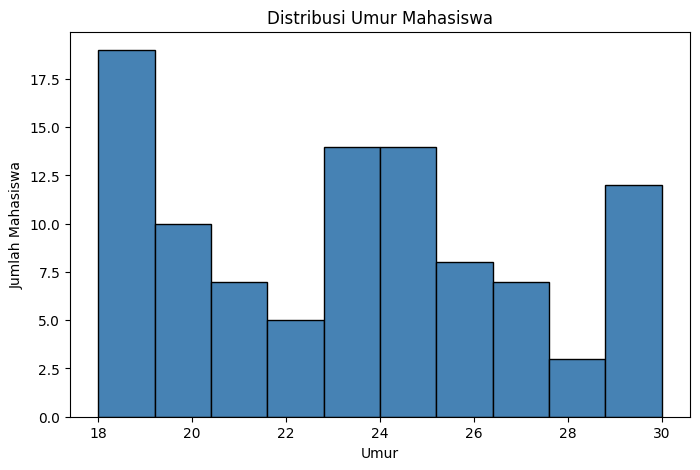

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Umur'],bins=10, color='steelblue', edgecolor="black")
plt.title("Distribusi Umur Mahasiswa")
plt.xlabel("Umur")
plt.ylabel("Jumlah Mahasiswa")
plt.show()


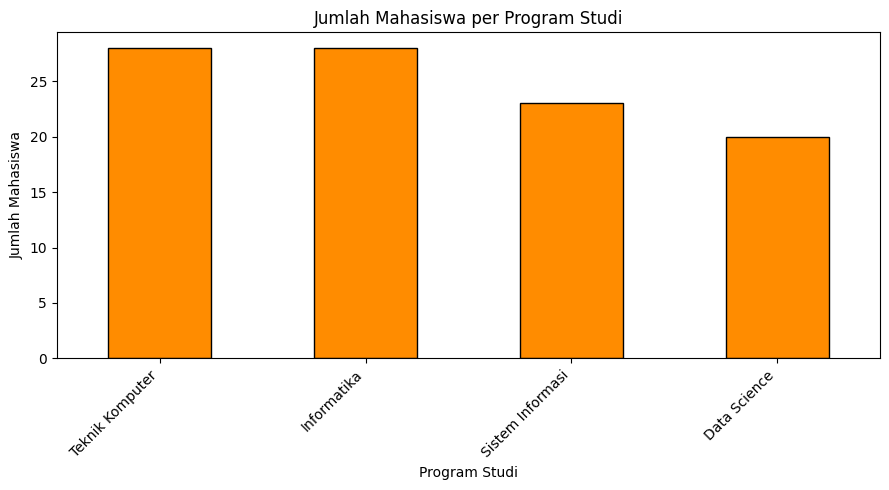

In [ ]:
plt.figure(figsize=(9, 5))
df_clean["Prodi"].value_counts().plot(kind="bar", color="darkorange", edgecolor="black")
plt.title("Jumlah Mahasiswa per Program Studi")
plt.xlabel("Program Studi")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()